In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
dataset = pd.DataFrame([[1000],[2000],[3000],[4000],[5000],[6000],[7000],[8000],[9000],[2000000000],[10000000000] ] , columns=['salary'])

In [5]:
pd.set_option('display.float_format','{:.2f}'.format)
dataset.describe()

,salary
count,11.00
mean,1090913181.82
std,3015111817.62
min,1000.00
25%,3500.00
50%,6000.00
75%,8500.00
max,10000000000.00


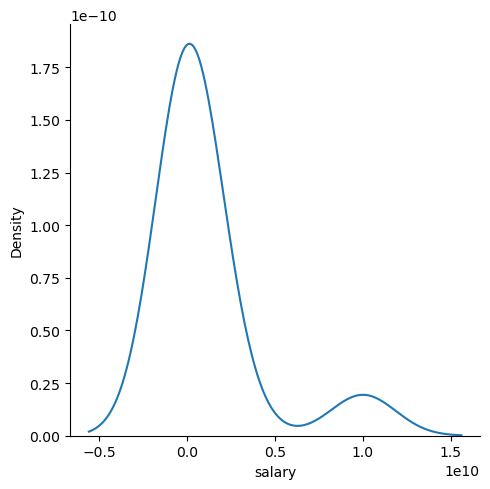

In [7]:
sns.displot(dataset['salary'],kind='kde')

In [8]:
# turkey method
def outlierdect(column):

    sorted(column)

    Q1,Q3 = np.percentile(column,[25,75])

    IRQ = Q3-Q1

    lowerRange = Q1-(1.5*IRQ)
    upperRange = Q3+(1.5*IRQ)

    return lowerRange,upperRange

In [9]:
lr,ur = outlierdect(dataset['salary'])
print(lr,ur)

-4000.0 16000.0


In [11]:
dataset[(dataset['salary']<lr) | (dataset['salary']>ur)]

,salary
9,2000000000
10,10000000000


In [17]:
dataset[ ( dataset['salary'] < lr ) | (dataset['salary'] > ur) ]

,salary
9,2000000000
10,10000000000


In [18]:
#Remove Outlier if present
processedDataset = dataset[ ( dataset['salary'] >= lr ) & (dataset['salary'] <= ur) ]

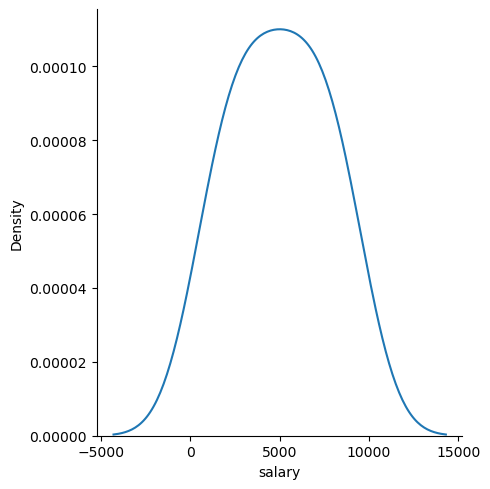

In [19]:
#kde = Kernel Density Estimation
sns.displot(processedDataset['salary'], kind="kde")

In [20]:
processedDataset['salary'].mean()

np.float64(5000.0)

# Check via zscore if the dataset['salary'] has any outliers

<Axes: ylabel='salary'>

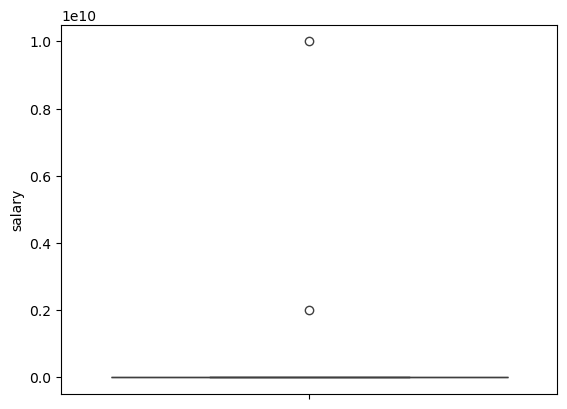

In [22]:
#boxplot

sns.boxplot(dataset['salary'])

<Axes: ylabel='salary'>

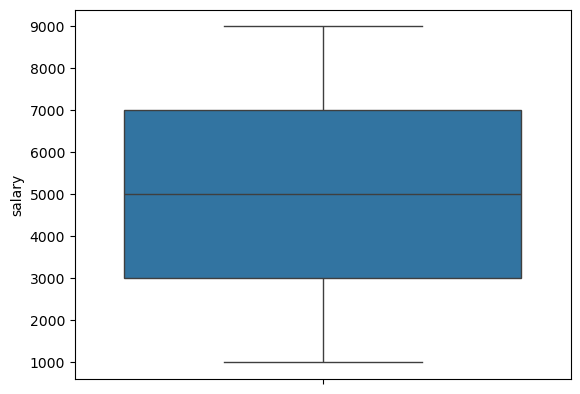

In [23]:
sns.boxplot(processedDataset['salary'])

In [24]:
#Detectinig Outliers
# 1. Tukeys Method (Numerical Way
# 2. Tukeys Method (Visual Way - Using Box Plot)
# 3. Z-score

# Rule of Z-score --- if value of zScore is greater than or equal to 3 ----> Outlier
# Zscore method is useful only when the column follows normal distribution

In [25]:
from scipy import stats
dataset['Z_score'] = stats.zscore(dataset['salary'])
dataset

,salary,Z_score
0,1000,-0.38
1,2000,-0.38
2,3000,-0.38
3,4000,-0.38
4,5000,-0.38
5,6000,-0.38
6,7000,-0.38
7,8000,-0.38
8,9000,-0.38
9,2000000000,0.32


In [26]:
prData1 = dataset[ dataset['Z_score'] < 3 ]
prData1

,salary,Z_score
0,1000,-0.38
1,2000,-0.38
2,3000,-0.38
3,4000,-0.38
4,5000,-0.38
5,6000,-0.38
6,7000,-0.38
7,8000,-0.38
8,9000,-0.38
9,2000000000,0.32


In [27]:
from scipy import stats
prData1['Z_score'] = stats.zscore(prData1['salary'])
prData1

C:\Users\shrid\AppData\Local\Temp\ipykernel_35620\2857755926.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prData1['Z_score'] = stats.zscore(prData1['salary'])


,salary,Z_score
0,1000,-0.33
1,2000,-0.33
2,3000,-0.33
3,4000,-0.33
4,5000,-0.33
5,6000,-0.33
6,7000,-0.33
7,8000,-0.33
8,9000,-0.33
9,2000000000,3.00


In [28]:
prData1 = prData1[ prData1['Z_score'] < 3 ]
prData1

,salary,Z_score
0,1000,-0.33
1,2000,-0.33
2,3000,-0.33
3,4000,-0.33
4,5000,-0.33
5,6000,-0.33
6,7000,-0.33
7,8000,-0.33
8,9000,-0.33
9,2000000000,3.00


In [29]:
prData1['Z_score'] < 3

0    True
1    True
2    True
3    True
4    True
5    True
6    True
7    True
8    True
9    True
Name: Z_score, dtype: bool

In [30]:
# OUTLIER REMOVAL
# ==================
#
# Step1: Check the distribution of the data column
#     if dis == "skew":
#          Step1: Apply Tukeys Method and remvoe outliers
#          Step2: Apply z-score over processed data column
#                    if dis == "normal" and zscore < 3:
#                          No Outliers
#                    else:
#                          Apply z-score and remove outliers
#
#
#     else:
#          Apply z-score over data column
#                    if zscore < 3:
#                          No Outliers
#                    else:
#                          Apply z-score and remove outliers
#